# 06a · Deep analysis of a trained PPO agent

Notebook **06** drives the RL stack end-to-end on a *tiny* budget — it proves the
mechanism (train → curves → CRN eval) in a couple of minutes, but the agent barely learns
and is expected to *lose* to the baseline. This notebook is the read-only companion: it
**loads a trained run from disk** and analyzes it in depth, re-running no training of its
own. It pairs with 06 the same way **05a** pairs with **05**.

What it does, all offline against the artifacts a run leaves under `runs/<experiment>/`:

1. **Training trajectory** — every scalar in the TensorBoard event file, including the full
   `eval/*` history over the run (not just the two noisy points a one-shot demo produces).
2. **Model selection** — the checkpoint with the best *held-out* `eval/paired_uplift` is
   often not the last one. We pick it explicitly and analyze *that* policy.
3. **Deep CRN comparison vs the `OrderUpToPolicy` default** on a **larger** held-out seed
   set than training used — aggregate KPIs, bootstrap CI on the uplift, win rate, and the
   per-seed picture.
4. **Regime analysis** — where the policy wins or loses across two orders of magnitude of
   node *capacity* and opening *balance* (does the scale-invariance hold?).
5. **Behavioral signature** — how the trained policy differs from the textbook rule on
   stockouts, turnover, and pricing.

### The run this notebook analyzes

To stay self-contained and fast (a couple of minutes, CPU-only, no LLM/GPU/API key), the
cell below **trains its own small run on demand** — a few eval-cadence checkpoints so the
model-selection and regime slices below have something real to chew on. It's the same
`src.rl.train` CLI 06 drives, just with a few more eval points; it writes to a gitignored
notebook directory and is skipped on re-run if the run already exists.

For a *serious* analysis, train a long run yourself and re-point `RUN_DIR` at it. A real
run is ~1M+ env steps with the production knobs (`--k-active 5 --episode-length 180
--k-catalog 100`), an eval checkpoint every 50k steps (~40 checkpoints to pick from over a
2M-step run):

```bash
uv run python -m src.rl.train \
  --total-env-steps 2000000 \
  --n-envs 8 \
  --episode-length 180 \
  --k-active 5 \
  --k-catalog 100 \
  --eval-cadence-env-steps 50000 \
  --n-eval-seeds 32 \
  --experiment-name ppo_long
```

Watch it live with `uv run tensorboard --logdir runs/` (the headline curve is
`eval/paired_uplift`); it's safe to stop early once that plateaus — the checkpoints already
written stay valid. Then set `RUN_DIR = Path("runs/ppo_long")` below and update the
`K_ACTIVE` / `K_CATALOG` / `EPISODE_LENGTH` knobs to match what you trained with.

> **Tiny-demo caveat.** With only a few thousand env steps the self-produced agent has barely
> begun to learn, so the textbook `OrderUpToPolicy` baseline is expected to win (negative
> `paired_uplift`, win-rate below 0.5). That is the correct outcome for a tiny budget — this
> notebook demonstrates the *analysis machinery*, not a competitive policy. Point `RUN_DIR`
> at a long run for a result worth defending.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Hop up to the repo root so `import src...` and relative paths resolve.
while not (Path.cwd() / "pyproject.toml").exists():
    os.chdir("..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
print("cwd:", Path.cwd())

cwd: /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator


## 1 · Point at a run (self-produced if absent)

`train.py` writes scalars and checkpoints but **not** the `RLConfig`, so the eval below has
to rebuild a matching one — hence we restate the knobs we trained with. The cell below
trains a small run into a gitignored notebook directory if it isn't already on disk; to
analyze your own long run instead, set `RUN_DIR` to `runs/<experiment-name>/` and align the
knobs. `K_active` is the one knob we can recover from the checkpoint itself (it fixes the
network's input width), so §1.1 **auto-detects and asserts** it as a guard against a
mismatched config.

In [2]:
# Knobs for the self-produced demo run. To analyze your own long run instead, set
# RUN_DIR = Path("runs/<experiment-name>/") and match these to what you trained with.
K_ACTIVE       = 3     # must match --k-active
K_CATALOG      = 12    # must match --k-catalog
EPISODE_LENGTH = 30    # must match --episode-length
N_EVAL_SEEDS   = 64    # held-out seeds for the deep eval (>= training's, for a tighter CI)

EXPERIMENT = "nb06a_demo"
RUN_ROOT   = "data/notebook_demos/06a/runs"   # gitignored; namespaced for this notebook
RUN_DIR    = Path(RUN_ROOT) / EXPERIMENT

# Self-produce a small run if it's not already on disk. A few thousand env steps with a
# tight eval cadence -> several eval-cadence checkpoints, enough for model selection (§3)
# and the regime slices (§5) to have something real to chew on. ~1-3 min on CPU.
if not RUN_DIR.is_dir():
    import subprocess, sys
    cmd = [
        "uv", "run", "python", "-m", "src.rl.train",
        "--total-env-steps", "8000",   # real run: ~1_000_000+
        "--n-envs", "2",               # real run: 8
        "--episode-length", str(EPISODE_LENGTH),
        "--k-active", str(K_ACTIVE),
        "--k-catalog", str(K_CATALOG),
        "--n-steps", "64",
        "--n-epochs", "4",
        "--n-minibatches", "2",
        "--eval-cadence-env-steps", "1000",   # ~8 eval checkpoints
        "--n-eval-seeds", "6",
        "--experiment-name", EXPERIMENT,
        "--tb-log-dir", RUN_ROOT,
        "--checkpoint-dir", RUN_ROOT,
    ]
    print("no run on disk — training a small one:\n ", " ".join(cmd), "\n")
    proc = subprocess.run(cmd, capture_output=True, text=True)
    print(f"return code: {proc.returncode}")
    tail = [ln for ln in proc.stderr.splitlines() if ln.strip()][-6:]
    print("\n".join(tail))
    assert proc.returncode == 0, "training subprocess failed"
else:
    print(f"reusing existing run: {RUN_DIR}")

assert RUN_DIR.is_dir(), (
    f"no such run dir: {RUN_DIR}. Train one first (see the command at the top), "
    "then point RUN_DIR at runs/<experiment-name>/."
)

event_files = sorted(RUN_DIR.glob("events.out.tfevents.*"))
ckpts       = sorted((RUN_DIR / "checkpoints").glob("actor_step*.pt"))
assert event_files, f"no TensorBoard event file under {RUN_DIR}"
assert ckpts, f"no checkpoints under {RUN_DIR}/checkpoints"

print(f"\nrun: {RUN_DIR}")
print(f"event file: {event_files[0].name}")
print(f"{len(ckpts)} checkpoints:")
shown = ckpts if len(ckpts) <= 6 else ckpts[:3] + ckpts[-3:]
for i, p in enumerate(shown):
    if len(ckpts) > 6 and i == 3:
        print("  ...")
    print(f"  {p.name}  ({p.stat().st_size / 1024:.0f} KB)")

no run on disk — training a small one:
  uv run python -m src.rl.train --total-env-steps 8000 --n-envs 2 --episode-length 30 --k-active 3 --k-catalog 12 --n-steps 64 --n-epochs 4 --n-minibatches 2 --eval-cadence-env-steps 1000 --n-eval-seeds 6 --experiment-name nb06a_demo --tb-log-dir data/notebook_demos/06a/runs --checkpoint-dir data/notebook_demos/06a/runs 



return code: 0
[train] SyncVectorEnv: 2 envs, obs_dim=58, act_dim=6
[train] TensorBoard log dir: data/notebook_demos/06a/runs/nb06a_demo
[train] Eval enabled: 6 seeds, cadence=1000 env steps.
[train] Starting PPO: total_env_steps=8000, seed=0
[train] Final checkpoint saved: data/notebook_demos/06a/runs/nb06a_demo/checkpoints/actor_step0000008000.pt
[train] Done.

run: data/notebook_demos/06a/runs/nb06a_demo
event file: events.out.tfevents.1780940776.Mislavs-MacBook-Pro.local.54212.0
8 checkpoints:
  actor_step0000000000.pt  (36 KB)
  actor_step0000000001.pt  (36 KB)
  actor_step0000000002.pt  (36 KB)
  ...
  actor_step0000000005.pt  (36 KB)
  actor_step0000000006.pt  (36 KB)
  actor_step0000008000.pt  (36 KB)


The checkpoint filenames are zero-padded so they sort chronologically: the eval-cadence
checkpoints come first (named by eval index `0, 1, 2, …`), and the **final** checkpoint —
named by the total env-step count — sorts last. We verify `K_active` against the network's
input layer (`obs_dim = K_active * 18 + 4`).

In [3]:
from src.rl.encoders import observation_dim, action_dim

# Recover obs_dim from the first Linear layer of any checkpoint: net.0.weight is
# (hidden_size, obs_dim). Then K_active = (obs_dim - 4) // 18  (N_PER_SKU=18, N_GLOBAL=4).
sd = torch.load(ckpts[-1], map_location="cpu")
obs_dim_ckpt = sd["net.0.weight"].shape[1]
k_active_ckpt = (obs_dim_ckpt - 4) // 18

assert k_active_ckpt == K_ACTIVE, (
    f"checkpoint was trained with K_active={k_active_ckpt} but K_ACTIVE={K_ACTIVE}. "
    "Fix K_ACTIVE to match the run."
)
print(f"checkpoint obs_dim = {obs_dim_ckpt}  ->  K_active = {k_active_ckpt}  (matches) ✓")

checkpoint obs_dim = 58  ->  K_active = 3  (matches) ✓


## 2 · The training trajectory

The event file holds the same scalars TensorBoard shows. On a real run the curves are long
enough to actually read: `losses/entropy` drifts down as the policy sharpens,
`train/episodic_return` trends up, and the `eval/*` series tells you whether that translated
into held-out performance. We **print the available tags first** and plot whichever exist.

In [4]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(str(event_files[0]))
ea.Reload()
scalar_tags = ea.Tags()["scalars"]
print(f"{len(scalar_tags)} scalar tags logged.")

def series(tag):
    "Return (steps, values) arrays for a scalar tag, or ([], []) if absent."
    if tag not in scalar_tags:
        return np.array([]), np.array([])
    evs = ea.Scalars(tag)
    return np.array([e.step for e in evs]), np.array([e.value for e in evs])

21 scalar tags logged.


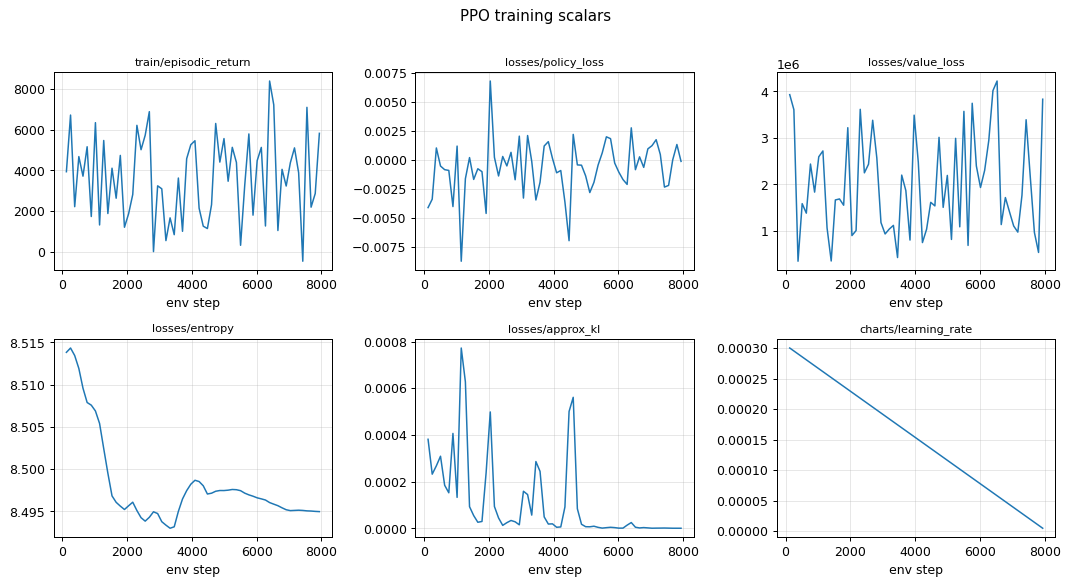

In [5]:
panel_tags = [
    "train/episodic_return", "losses/policy_loss", "losses/value_loss",
    "losses/entropy", "losses/approx_kl", "charts/learning_rate",
]
present = [t for t in panel_tags if t in scalar_tags]
ncol = 3
nrow = (len(present) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3.2 * nrow))
axes = axes.ravel()
for ax, tag in zip(axes, present):
    steps, vals = series(tag)
    ax.plot(steps, vals, lw=1.2)
    ax.set_title(tag, fontsize=9)
    ax.set_xlabel("env step")
    ax.grid(alpha=0.3)
for ax in axes[len(present):]:
    ax.axis("off")
fig.suptitle("PPO training scalars", y=1.01)
plt.tight_layout()
plt.show()

### The held-out `eval/*` trajectory

The bottom line. Left: mean episode return, RL vs baseline, over training. Right:
`eval/paired_uplift` (mean per-seed RL − baseline on identical worlds) with `eval/win_rate`
overlaid. A **positive and stable** uplift is the goal; a curve that rises then degrades
is why §3 selects the *best* checkpoint rather than the last.

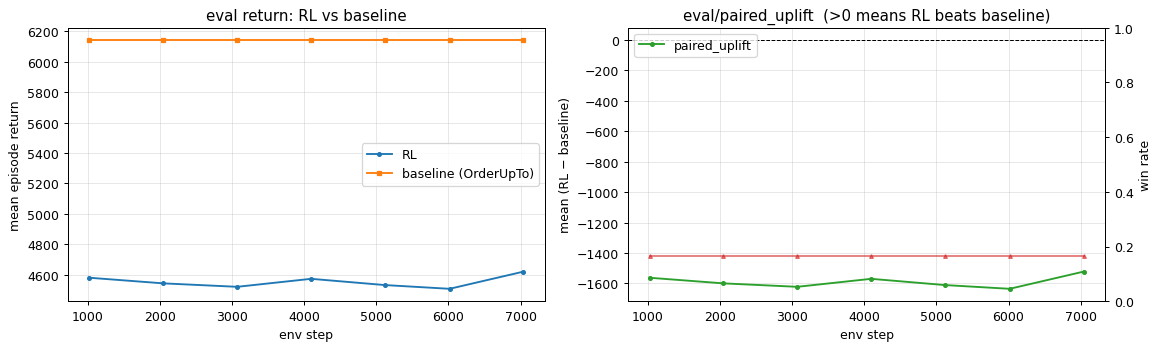

final logged paired_uplift : -1,522.4
best  logged paired_uplift : -1,522.4  (at env step 7,040)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

s_rl, v_rl = series("eval/rl_return")
s_bl, v_bl = series("eval/baseline_return")
if len(v_rl): axes[0].plot(s_rl, v_rl, marker="o", ms=3, label="RL")
if len(v_bl): axes[0].plot(s_bl, v_bl, marker="s", ms=3, label="baseline (OrderUpTo)")
axes[0].set_title("eval return: RL vs baseline")
axes[0].set_xlabel("env step"); axes[0].set_ylabel("mean episode return")
axes[0].legend(); axes[0].grid(alpha=0.3)

s_up, v_up = series("eval/paired_uplift")
s_wr, v_wr = series("eval/win_rate")
ax = axes[1]
if len(v_up):
    ax.plot(s_up, v_up, marker="o", ms=3, color="C2", label="paired_uplift")
    ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_title("eval/paired_uplift  (>0 means RL beats baseline)")
ax.set_xlabel("env step"); ax.set_ylabel("mean (RL − baseline)")
ax.grid(alpha=0.3)
if len(v_wr):
    axb = ax.twinx()
    axb.plot(s_wr, v_wr, marker="^", ms=3, color="C3", alpha=0.6, label="win_rate")
    axb.set_ylabel("win rate"); axb.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

if len(v_up):
    print(f"final logged paired_uplift : {v_up[-1]:+,.1f}")
    print(f"best  logged paired_uplift : {v_up.max():+,.1f}  (at env step {int(s_up[v_up.argmax()]):,})")

## 3 · Pick the checkpoint to analyze

The eval-cadence checkpoints line up one-for-one with the logged `eval/*` points (both fire
on the same schedule), so the checkpoint at the **best** `eval/paired_uplift` is the one
worth keeping — picking the last checkpoint is a common mistake when the curve has already
turned over. We map eval index → checkpoint and select the best, falling back to the final
checkpoint if no eval series was logged.

In [7]:
# Eval-cadence checkpoints are named by eval index (0,1,2,…); the final checkpoint is named
# by total_env_steps and sorts last. Align the cadence checkpoints with the eval series.
cadence_ckpts = ckpts[:-1] if len(ckpts) > 1 else ckpts

if len(v_up) and len(cadence_ckpts) >= len(v_up):
    best_eval_idx = int(v_up.argmax())
    chosen_ckpt = cadence_ckpts[best_eval_idx]
    reason = (f"best eval/paired_uplift ({v_up[best_eval_idx]:+,.1f}) "
              f"at env step {int(s_up[best_eval_idx]):,}")
else:
    chosen_ckpt = ckpts[-1]
    reason = "final checkpoint (no usable eval series to select on)"

print(f"final  checkpoint : {ckpts[-1].name}")
print(f"chosen checkpoint : {chosen_ckpt.name}")
print(f"  -> {reason}")

final  checkpoint : actor_step0000008000.pt
chosen checkpoint : actor_step0000000006.pt
  -> best eval/paired_uplift (-1,522.4) at env step 7,040


## 4 · Deep CRN comparison vs the textbook default

We load the chosen actor and re-run the **exact** CRN evaluation `train.py` uses — but on
`N_EVAL_SEEDS` held-out seeds (more than training logged, for a tighter estimate). The
baseline is a fresh `OrderUpToPolicy()`. For each seed the RL and baseline arms share
`(world_seed, capacity, balance, active subset, slot permutation)`, so any gap is the policy
alone. We collect **per-seed** returns and KPIs by calling `evaluate(...)` one spec at a
time — the trick that exposes detail the aggregate hides.

In [8]:
from src.rl.agents.ppo import Actor
from src.rl.configs.default import RLConfig
from src.rl.episode_sampler import make_synthetic_catalog
from src.rl.eval import build_eval_seeds, evaluate
from src.sim.policy import OrderUpToPolicy

cfg = RLConfig(K_active=K_ACTIVE, K_catalog=K_CATALOG, episode_length=EPISODE_LENGTH)

actor = Actor(observation_dim(cfg.K_active), action_dim(cfg.K_active))
actor.load_state_dict(torch.load(chosen_ckpt, map_location="cpu"))
actor.eval()

def rl_policy_fn(obs_np):
    obs_t = torch.tensor(obs_np, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        action, _, _ = actor.get_action_and_log_prob(obs_t)
    return action.squeeze(0).numpy()

catalog = make_synthetic_catalog(cfg.K_catalog)
eval_specs = build_eval_seeds(catalog, cfg, n_seeds=N_EVAL_SEEDS)
print(f"built {len(eval_specs)} held-out CRN eval specs")

KPIS = ["return", "net_profit", "stockout_rate",
        "inventory_turnover", "mean_price_pct_of_msrp"]

rows = []
for i, spec in enumerate(eval_specs):
    m = evaluate(rl_policy_fn, lambda: OrderUpToPolicy(), [spec], config=cfg)
    row = {"seed_idx": i, "capacity": spec.capacity, "balance": spec.balance}
    for kpi in KPIS:
        row[f"rl_{kpi}"] = m.get(f"eval/rl_{kpi}", np.nan)
        row[f"bl_{kpi}"] = m.get(f"eval/baseline_{kpi}", np.nan)
    rows.append(row)
ev = pd.DataFrame(rows)
ev["uplift"] = ev["rl_return"] - ev["bl_return"]
print(f"per-seed table: {ev.shape[0]} rows")
ev.head()

built 64 held-out CRN eval specs


per-seed table: 64 rows


,seed_idx,capacity,balance,rl_return,bl_return,rl_net_profit,bl_net_profit,rl_stockout_rate,bl_stockout_rate,rl_inventory_turnover,bl_inventory_turnover,rl_mean_price_pct_of_msrp,bl_mean_price_pct_of_msrp,uplift
0,0,3340,886466.945379,6228.35,6228.35,6228.35,6228.35,0.000000,0.000000,0.257379,0.257379,1.0,1.0,0.00
1,1,683,590061.133942,7304.33,7657.20,7304.33,7657.20,0.055556,0.000000,1.863386,1.892167,1.0,1.0,-352.87
2,2,153,150099.034410,1506.20,2997.38,1506.20,2997.38,0.466667,0.033333,5.038902,11.683538,1.0,1.0,-1491.18
3,3,124,275879.936029,1506.53,4996.59,1506.53,4996.59,0.488889,0.022222,6.933775,14.134420,1.0,1.0,-3490.06
4,4,1377,35163.324420,8370.38,8666.38,8370.38,8666.38,0.000000,0.000000,0.755142,0.755142,1.0,1.0,-296.00


### Headline: aggregate KPIs, uplift, and a bootstrap CI

The aggregate RL-vs-baseline KPI table, plus the paired uplift with a 95% bootstrap
confidence interval over seeds. A CI **strictly above zero** is the honest claim that the
policy beats the textbook rule on held-out worlds — not just on lucky draws.

In [9]:
agg = pd.DataFrame({
    "RL":       [ev[f"rl_{k}"].mean() for k in KPIS],
    "baseline": [ev[f"bl_{k}"].mean() for k in KPIS],
}, index=KPIS)
agg["RL − baseline"] = agg["RL"] - agg["baseline"]
display(agg.round(3))

# Paired bootstrap CI on the per-seed uplift.
rng = np.random.default_rng(0)
uplift = ev["uplift"].to_numpy()
boot = rng.choice(uplift, size=(10_000, len(uplift)), replace=True).mean(axis=1)
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
win_rate = (uplift >= 0).mean()

print(f"\npaired uplift (mean RL − baseline net profit/seed) : {uplift.mean():+,.1f}")
print(f"95% bootstrap CI                                   : [{ci_lo:+,.1f}, {ci_hi:+,.1f}]")
print(f"win rate (seeds where RL >= baseline)              : {win_rate:.0%}  "
      f"({int((uplift >= 0).sum())}/{len(uplift)})")
verdict = ("a real improvement over the default" if ci_lo > 0 else
           "NOT clearly better than the default (CI spans 0)")
print(f"\nVerdict: the trained policy is {verdict}.")

,RL,baseline,RL − baseline
return,3479.212,4908.401,-1429.189
net_profit,3479.212,4908.401,-1429.189
stockout_rate,0.175,0.005,0.170
inventory_turnover,2.086,3.523,-1.437
mean_price_pct_of_msrp,1.000,1.000,0.000



paired uplift (mean RL − baseline net profit/seed) : -1,429.2
95% bootstrap CI                                   : [-1,888.7, -989.4]
win rate (seeds where RL >= baseline)              : 39%  (25/64)

Verdict: the trained policy is NOT clearly better than the default (CI spans 0).


### The per-seed picture

Left: every held-out seed as (baseline, RL) on the 45° line — points **above** the line are
RL wins. Outliers far below the line are regimes the policy mishandles. Right: the
distribution of per-seed uplift, with its mean.

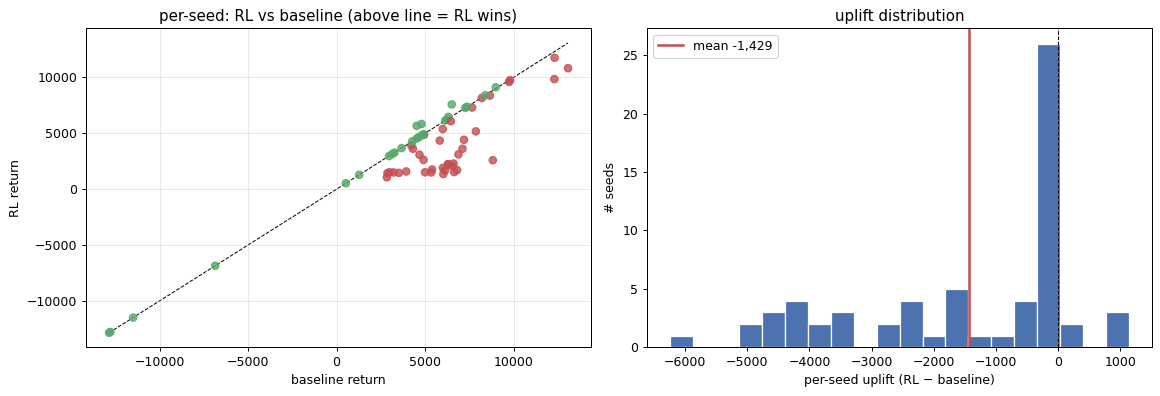

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

lo = min(ev["bl_return"].min(), ev["rl_return"].min())
hi = max(ev["bl_return"].max(), ev["rl_return"].max())
axes[0].plot([lo, hi], [lo, hi], color="k", lw=0.8, ls="--", zorder=1)
colors = np.where(ev["uplift"] >= 0, "#55A868", "#C44E52")
axes[0].scatter(ev["bl_return"], ev["rl_return"], c=colors, s=35, alpha=0.8, zorder=3)
axes[0].set_xlabel("baseline return"); axes[0].set_ylabel("RL return")
axes[0].set_title("per-seed: RL vs baseline (above line = RL wins)")
axes[0].grid(alpha=0.3)

axes[1].hist(uplift, bins=20, color="#4C72B0", edgecolor="white")
axes[1].axvline(0, color="k", lw=0.8, ls="--")
axes[1].axvline(uplift.mean(), color="#C44E52", lw=2, label=f"mean {uplift.mean():+,.0f}")
axes[1].set_xlabel("per-seed uplift (RL − baseline)"); axes[1].set_ylabel("# seeds")
axes[1].set_title("uplift distribution")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5 · Regime analysis — does the scale-invariance hold?

Each episode draws a node *capacity* and opening *balance* **log-uniform across two orders
of magnitude**, and the whole point of the scale-invariance package (order-up-to action
decoder, demand-units inventory feature) is that *one* policy generalises across that range.
Here we slice the per-seed uplift by capacity and balance to see **where** the policy wins
or loses — a flat, positive band across all sizes is the result you want; a slope means the
policy is tuned to one end of the range.

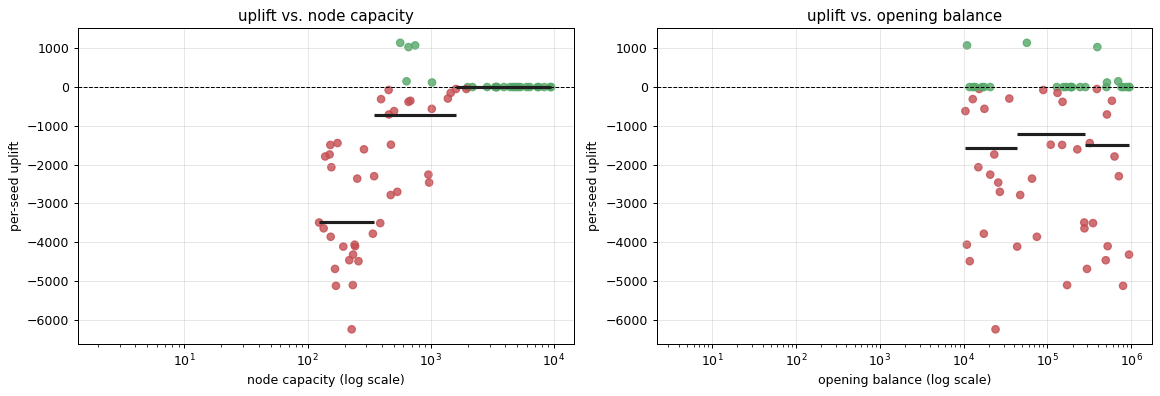

mean uplift by capacity tercile:
capacity
(123.999, 347.0]   -3465.4
(347.0, 1601.0]     -722.9
(1601.0, 9510.0]      -2.4


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, label in [(axes[0], "capacity", "node capacity"),
                       (axes[1], "balance", "opening balance")]:
    colors = np.where(ev["uplift"] >= 0, "#55A868", "#C44E52")
    ax.scatter(ev[col], ev["uplift"], c=colors, s=35, alpha=0.8)
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xscale("log")
    ax.set_xlabel(f"{label} (log scale)"); ax.set_ylabel("per-seed uplift")
    ax.set_title(f"uplift vs. {label}")
    ax.grid(alpha=0.3)

    # binned means (terciles on the log axis) to read the trend through the noise.
    q = pd.qcut(ev[col], q=3, duplicates="drop")
    binned = ev.groupby(q, observed=True)["uplift"].mean()
    for interval, val in binned.items():
        ax.hlines(val, interval.left, interval.right, color="#1f1f1f", lw=2.5, zorder=4)
plt.tight_layout()
plt.show()

print("mean uplift by capacity tercile:")
print(ev.groupby(pd.qcut(ev["capacity"], 3, duplicates="drop"),
                 observed=True)["uplift"].mean().round(1).to_string())

## 6 · Behavioral signature — *how* does the policy differ?

Beyond the bottom line: the per-seed KPI distributions show *how* the learned policy departs
from the textbook rule. A lower stockout rate at comparable turnover means it ordered
better; the price-%-of-MSRP panel surfaces whether the agent is pulling its profit from
*pricing* rather than from *ordering*. Box pairs are RL (blue) vs baseline (orange) across
all held-out seeds.

> The CRN evaluator (`src/rl/eval.py`) reports the KPIs recoverable from observable traces —
> return, net profit, stockout rate, turnover, and price % of MSRP — so those are what we
> compare here.

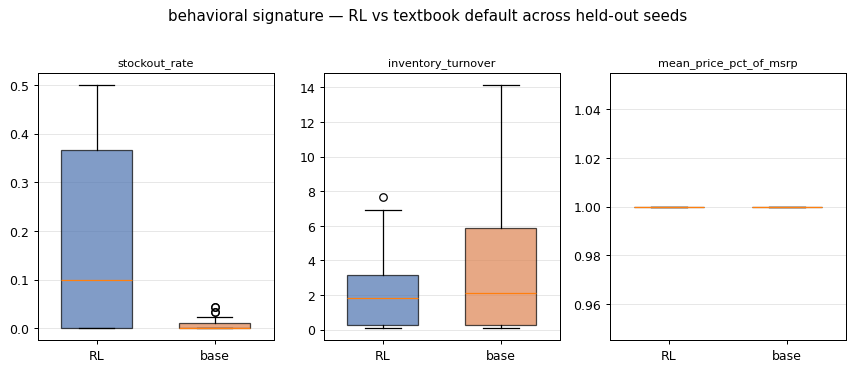

mean by KPI (RL vs baseline):


,RL,baseline,RL − baseline
stockout_rate,0.175,0.005,0.170
inventory_turnover,2.086,3.523,-1.437
mean_price_pct_of_msrp,1.000,1.000,0.000


In [12]:
behavior_kpis = ["stockout_rate", "inventory_turnover", "mean_price_pct_of_msrp"]
fig, axes = plt.subplots(1, len(behavior_kpis), figsize=(3.2 * len(behavior_kpis), 4))
for ax, kpi in zip(axes, behavior_kpis):
    data = [ev[f"rl_{kpi}"].dropna(), ev[f"bl_{kpi}"].dropna()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6)
    for box, c in zip(bp["boxes"], ["#4C72B0", "#DD8452"]):
        box.set_facecolor(c); box.set_alpha(0.7)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["RL", "base"])
    ax.set_title(kpi, fontsize=9)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("behavioral signature — RL vs textbook default across held-out seeds", y=1.02)
plt.tight_layout()
plt.show()

print("mean by KPI (RL vs baseline):")
display(agg.loc[behavior_kpis].round(3))

## Where to next

- Re-point `RUN_DIR` at any other `runs/<experiment>/` to compare sweeps — overlay their
  `eval/paired_uplift` curves in TensorBoard (`uv run tensorboard --logdir runs/`) to pick
  which run to deep-dive here.
- Train longer or on a real catalog: add `--setup-dir setups/<name>` to the training command
  (then load that setup's catalog here instead of the synthetic one for the eval to match).
- For the strongest textbook bar, swap the baseline `OrderUpToPolicy()` for the **tuned**
  winner from notebook **05a**'s study (`OrderUpToPolicy(**best_params)`), and re-run §4 —
  the CRN guarantee still holds.
- `src/rl/README.md` — observation/action layout, checkpoint format, and the CRN eval contract.

| notebook | topic |
|---|---|
| **06** | train a PPO agent & evaluate it — *how to drive the stack* |
| **06a** | deep analysis of a long-trained run from disk — *this notebook* |
| **05a** | analyze a completed tuning study (the baseline this agent is measured against) |